<a href="https://colab.research.google.com/github/oliviapang/DS_3001_Assignments/blob/main/Assignment_3/3_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1

1. A model is 'linear' because it assumes a linear relationship between the input and target/output variables. Each term is
weighted by a coefficient, creating the equation for a line. Additionally, if a function is multiplied by a scalar and returns
a linear funciton, it is linear.
2. The coefficient for a dummy variable represents how much the target variable changes for each unit of the input, as compared
to the dropped/reference column. The intercept of the model represents the value of the dropped column.
3. Technically, linear regression can be used for classification if you use it to calculate probabilities and set a threshold for
classification (e.g. > 0.5 is 1 and < 0.5 is 0). However, linear regression can return values less than 0 and greater than 1, which
can't really be interpreted as probabilities.
4. One sign a model is overfitting is if it performs well on training data but poorly on the test set. This indicates that it is
"seeing" patterns in the training data that aren't there. Another sign is higher variance in predictions. Models that are too
complex tend to have high variance and overfit the data.
5. The first stage of the two-stage least squares technique involves running a regression between y and an independent variable
(xk) on all other independent variables. Residuals are calculated for y and xk. Then, a single linear regression is run on those
residuals. Multi-colinearity occurs when two independent variables explain the same changes in target variable. The coefficients found
for those variables in the first stage regression will not reflect the predictor's singular effect on the target variable;
instead, they will represent the variables partial effect, greatly impacted by which other variable are present in the model. The
highly correlated variables will effectively cancel each other out, producing a hightly variable model.
6. Nonlinear relationships between the target and independent variables can be introduced via latent variable models. A latent
variable (say, x1*b) is passed into a nonlinear activation function, and a prediction value is obtained. Depending on the desired
outcome, different activation functions can be used.
7. The slope coefficient represents how much the target value will change for each unit input value.
8. Train/test split divides the data once, and trains the model only on that one set of training data. In k-fold cross validation,
the data is split into k folds/chunks and, trained on k-1 chunks, and tested on the kth chunk. This process repeats k times.
9. There is not a set way to select k, and its value depends on bias or variance you want the model to have. A low k-value will
be faster to compute but may be more biased because it had fewer training sets. A higher k-value will provide bias but may have
more variance if the model is overfitting the data. Additionally, if the data set is small, a higher k value may be necessary to ensure
there is enough training data.

Question 2

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1
! git clone https://github.com/oliviapang/DS_3001_Assignments

Cloning into 'DS_3001_Assignments'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (51/51), done.
Receiving objects: 100% (59/59), 1.71 MiB | 19.43 MiB/s, done.
remote: Total 59 (delta 15), reused 16 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (15/15), done.


In [ ]:
df = pd.read_csv('/content/DS_3001_Assignments/Assignment_3/Q1_clean.csv')
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [ ]:
df.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')

In [ ]:
print(df.groupby('Neighbourhood ')['Price'].mean())
print(df.groupby('Neighbourhood ')['Review Scores Rating'].mean())

Neighbourhood 
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: Price, dtype: float64
Neighbourhood 
Bronx            91.654378
Brooklyn         92.363497
Manhattan        91.801496
Queens           91.549057
Staten Island    90.843750
Name: Review Scores Rating, dtype: float64


On average, Manhattan is the most expensive.

<Axes: xlabel='Price', ylabel='Density'>

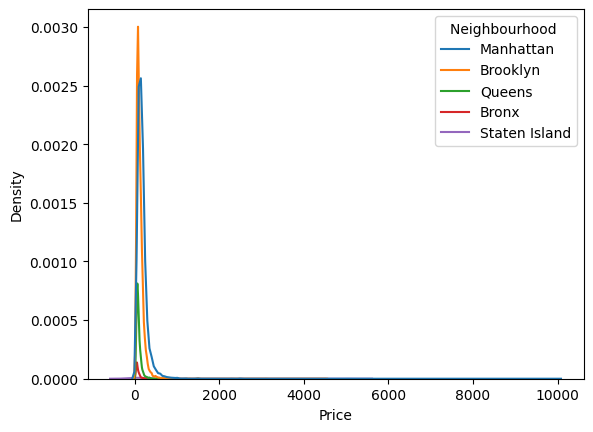

In [ ]:
# price
sns.kdeplot(data = df, x = df['Price'], hue = 'Neighbourhood ')

<Axes: xlabel='Price', ylabel='Density'>

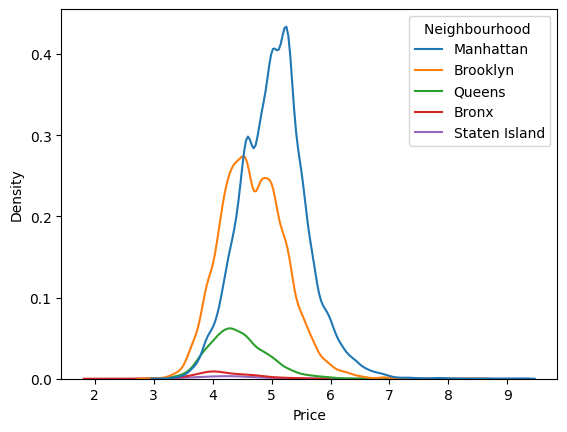

In [ ]:
# log price
sns.kdeplot(data = df, x = np.log(df['Price']), hue = 'Neighbourhood ')

In [ ]:
# 2
from sklearn.linear_model import LinearRegression

X = pd.get_dummies(df['Neighbourhood '], drop_first = True) # independent
y = df['Price'] # target
model = LinearRegression()
model = model.fit(X, y)
print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 75.27649769585331


,variable,coefficient
0,Brooklyn,52.470881
1,Manhattan,108.387789
2,Queens,21.580735
3,Staten Island,70.890169


The coefficients here represent the change in price for each neighbourhood as compared to the mean price for the Bronx (the
dropped category). For example, a location in Brooklyn will add $52.47 to the mean Bronx price, making the price total $127.75
The conditional group means equal the Bronx mean plus their corresponding estimated coefficient.

In [ ]:
# 3
X = df[['Review Scores Rating']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(f"Slope (Review Scores Rating): {model.coef_[0]}")

Model intercept: 60.878390657123546
Slope (Review Scores Rating): 1.0208266022674763


The slope coefficient represents how much the price will change if the review score increases by one unit (1 point). Here, the
price will go up by about $1.02 for each one point increase in the review score.

In [ ]:
# 4
X_neighbourhood = pd.get_dummies(df['Neighbourhood '], drop_first = True)
X_review = df.loc[:, 'Review Scores Rating']
X = pd.concat([X_neighbourhood, X_review], axis = 1)
y = df['Price']
model = LinearRegression()
model = model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: -23.812561011672244


,variable,coefficient
0,Brooklyn,51.704240
1,Manhattan,108.228737
2,Queens,21.694600
3,Staten Island,71.766552
4,Review Scores Rating,1.081116


The slope on "Review Scores Rating" increased slightly. The "Neighbourhood" averages increased slightly for Brooklyn and Manhattan
and decreased slightly for Queens and Staten Island.

In [ ]:
# 5
neighbourhoods = pd.get_dummies(df['Neighbourhood '], dtype = 'int')
neighbourhoods
X = neighbourhoods.mul(df['Review Scores Rating'], axis = 0) # multiply dummy dataframe by Review Score; 1 means listing is in that neighbourhood, score is kept instead of going to 0
y = df['Price']
model = LinearRegression()
model = model.fit(X, y)
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })


,variable,coefficient
0,Bronx,0.222718
1,Brooklyn,0.790947
2,Manhattan,1.399376
3,Queens,0.456451
4,Staten Island,0.682444


The slopes are not similar across neighbourhoods

In [ ]:
# 6
# The question says to compare models from parts 4, 5, and 6, but this is part 6 so I am going to assume that I am just comparing models from 4 and 5

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

X4 = pd.concat([X_neighbourhood, X_review], axis = 1)
X5 = neighbourhoods.mul(df['Review Scores Rating'], axis = 0)
y = df['Price']
model = LinearRegression()

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds

scores = -cross_val_score(model, X4, y, cv=kfold, scoring = 'neg_mean_squared_error')

# for model in part 4
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print('\n')

# for model in part 5
scores = -cross_val_score(model, X5, y, cv=kfold, scoring = 'neg_mean_squared_error')
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))

Fold scores: [13328.8844614  17923.91602978 22359.73425128 20638.78463036
 16213.77913811 15968.25148456 65543.4120206  11112.83183507
 12726.79546542 14924.58455652]
Mean score: 21074.09738730938
Median score: 16091.015311334519
Std dev: 15184.490093017015


Fold scores: [13311.07229932 17954.60039454 22387.19337011 20619.21550811
 16175.84243945 15946.8948861  65402.49266663 11078.49494357
 12712.73515709 14905.03305142]
Mean score: 21049.357471633004
Median score: 16061.368662774752
Std dev: 15149.555684425934


The second model appears to be better as its mean k-fold mean squared error is lower.

Question 3

In [ ]:
! git clone https://github.com/oliviapang/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 66 (delta 17), reused 5 (delta 5), pack-reused 35 (from 2)
Receiving objects: 100% (66/66), 1.52 MiB | 1.36 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Download complete
Extracting data files...
Data extracted


<Figure size 640x480 with 0 Axes>

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


<Axes: xlabel='Price', ylabel='Density'>

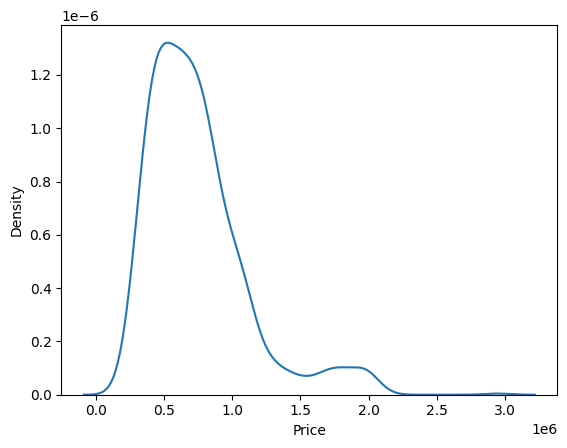

In [ ]:
# 1
df = pd.read_csv('/content/data/cars_hw.csv')
print(df['Price'].describe())
sns.kdeplot(data = df, x = df['Price'])

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


<Axes: xlabel='Price', ylabel='Density'>

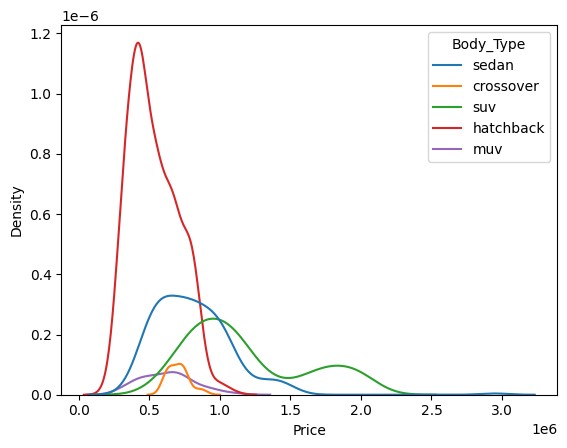

In [ ]:
print(df.groupby('Body_Type')['Price'].describe())
sns.kdeplot(data = df, x = df['Price'], hue = 'Body_Type')

On average, SUVs are the most expensive. They also have the most variance.

In [ ]:
df.loc[:,'Seating_Capacity']

,Seating_Capacity
0,5
1,5
2,5
3,5
4,5
...,...
971,5
972,5
973,5
974,5


In [ ]:
# 2
X = df[['Seating_Capacity']]
y = df['Price']
model = LinearRegression()
model.fit(X, y)

print(f"Slope (Review Scores Rating): {model.coef_[0]}")

Slope (Review Scores Rating): 59267.99803672175


The slope coefficient is 59268. This means that the price increases $59,268 for each seat added.

In [ ]:
X = pd.get_dummies(df['Seating_Capacity'])
X.columns = ['4', '5', '6', '7', '8']
y = df['Price']
model = LinearRegression(fit_intercept=False) # dropping intercept instead of first category this time
model.fit(X, y)

pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

,variable,coefficient
0,4,1.880000e+05
1,5,7.344839e+05
2,6,1.644000e+06
3,7,9.239487e+05
4,8,4.598000e+05


No, the difference in prices are not linear. The jump between 4 and 5 seats corresponds to a difference of about $546,000, and
the jump from 5 to 6 seats sees an even greater price difference. The price then drops going from 6 to 7 and 7 to 8 seats.

In [ ]:
# 3
from sklearn.preprocessing import PolynomialFeatures

df['Age'] = 2026 - df['Make_Year'] # calculate vehicle age based on its make year
X = df[['Age']]

mse = []

for i in range(1, 11):
  expander = PolynomialFeatures(degree=i,include_bias=False)
  X_poly = expander.fit_transform(X)

  model = LinearRegression()
  scores = cross_val_score(model, X_poly, y, cv=10, scoring= 'neg_mean_squared_error')
  mse.append(-scores.mean())

mse



[np.float64(100295370079.45541),
 np.float64(100814620596.42151),
 np.float64(100380163091.91858),
 np.float64(100474431121.09933),
 np.float64(100131346193.80983),
 np.float64(100347765612.3735),
 np.float64(99809273931.78845),
 np.float64(100029779979.77138),
 np.float64(100134700414.28859),
 np.float64(100077595092.0118)]

According to this, a seventh degree polynomial is most optimal as the mean squared error is lowest.

<Axes: xlabel='Age', ylabel='Price'>

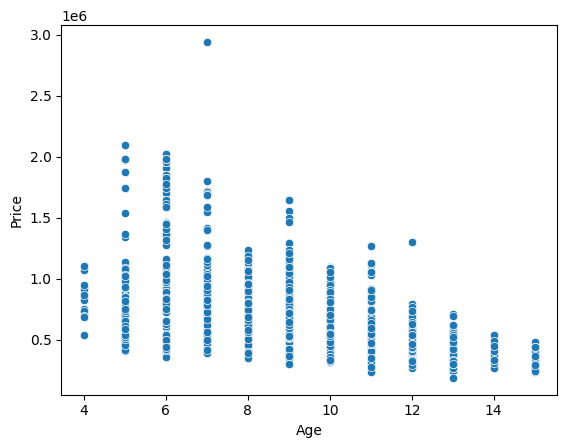

In [ ]:
# 4
# price vs. age
sns.scatterplot(data = df, x = df['Age'], y = df['Price'])

<Axes: xlabel='Age', ylabel='Price'>

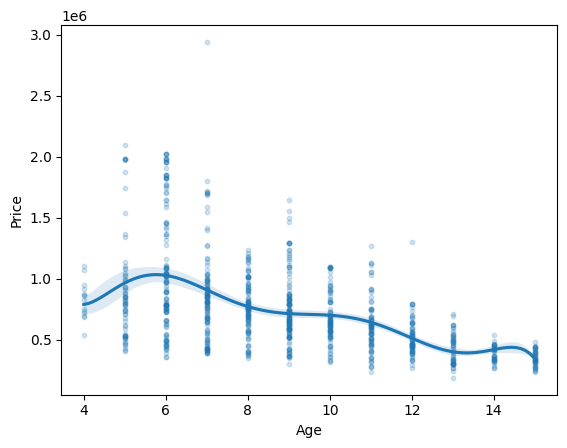

In [ ]:
# model predicted price vs. age
sns.regplot(data = df, x = df['Age'], y = df['Price'], order = 7, scatter_kws={'alpha': 0.2, "s": 10})

The model does seem to accurately fit patterns in the data. However, because it is a high order model it reacts to small details
in trends, making it susceptible to overfitting and high variance.

Question 4

In [ ]:
df = pd.read_csv('/content/DS_3001_Assignments/Assignment_3/heart_hw.csv')
df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [ ]:
# 1
print(pd.crosstab(df['transplant'], df['y']))
a = 4/34 # portion of survivors in control
print(a)
b = 24/69 # portion of survivors in treatment
print(b)
ATE = b - a
print(ATE)

y            0   1
transplant        
control     30   4
treatment   45  24
0.11764705882352941
0.34782608695652173
0.23017902813299232


The ATE is about 0.2302

In [ ]:
# 2
df['transplant_numeric'] = df['transplant'].map({'control': 0, 'treatment': 1}) # map categorigal data to numbers
X = df[['transplant_numeric']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
print(f"Slope: {model.coef_[0]}")

Model intercept: 0.1176470588235293
Slope: 0.23017902813299249


The intercept is the same as the proportion of survivors in the control group. The slope is the same as the ATE.

In [ ]:
# 3
X = df.loc[:, ['age', 'transplant_numeric']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 0.7019569721740946


,variable,coefficient
0,age,-0.013607
1,transplant_numeric,0.264702


The coefficient on transplant increased slightly once we controlled for age. The intercept represents the proportion of survivors
when age is 0 and the patient is not treated (control group). The age slope represents the change in probability of survival for
every year increase in age. Here, survival probability decreases as the patient gets older. The transplant slope represents the
change in survival probability if the patient goes from no transplant (0) to having a transplant (1). This is the ATE.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

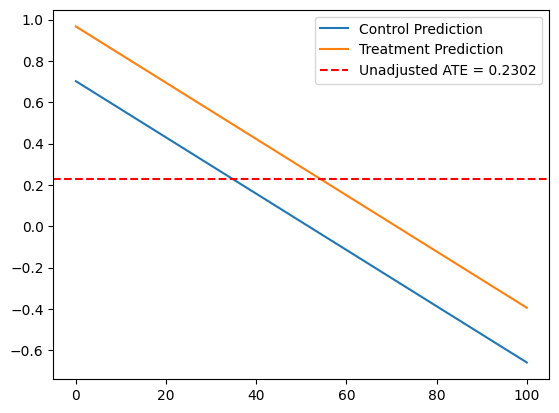

In [ ]:
range = np.linspace(0, 100)
phat_control = model.predict(pd.DataFrame({'age': range, 'transplant_numeric': 0}))
phat_treatment = model.predict(pd.DataFrame({'age': range, 'transplant_numeric': 1}))

plt.plot(range, phat_control, label = 'Control Prediction')
plt.plot(range, phat_treatment, label = 'Treatment Prediction')
plt.axhline(y=0.2302, color='red', linestyle='--', label='Unadjusted ATE = 0.2302')
plt.legend()
plt

In the control group, the ATE underestimaes for ages 0 to about 35 and overestimaes for around 35 and up. In the treament group,
the ATE underestimates for ages 0 to 50 and overestimates for ages 50 and up.

In [ ]:
# 4
df['age_transplant'] = df['age']*df['transplant_numeric']
X = df.loc[:, ['age', 'transplant_numeric', 'age_transplant']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

print(f'Model intercept: {model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept: 0.35486517529946177


,variable,coefficient
0,age,-0.005524
1,transplant_numeric,0.907751
2,age_transplant,-0.014591


When we control for age, transplant, and age * transplant the coefficient on transplant increases from the coefficient on the basic
regression. Here, the intercept represents probability of survival when age is 0 and transplant is 0 (control group). Age * transplant
will also go to zero when these conditions are true. The slope on age represents the change in probability of survival for every
year. The slope on transplant represents the change in probability of survival if the patient goes from no transplant (0) to having
a transplant (1). The slope on age*transplant represents the change in probability of survival having to do with the interaction
between age and transplant status.

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

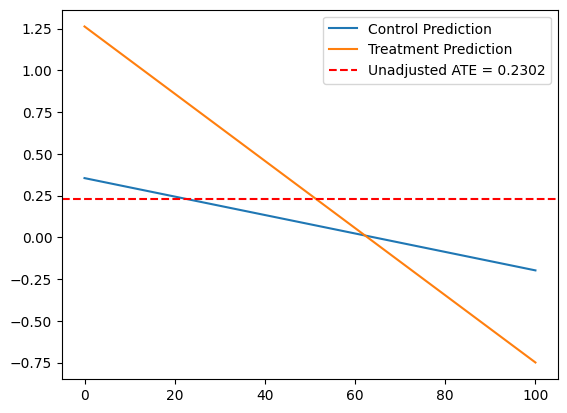

In [ ]:
phat_control = model.predict(pd.DataFrame({'age': range, 'transplant_numeric': 0, 'age_transplant':0})) # any age multiplied by transplant status of 0 is 0
phat_treatment = model.predict(pd.DataFrame({'age': range, 'transplant_numeric': 1, 'age_transplant': range })) # any age multipled by transplant status of 1 is just the age

plt.plot(range, phat_control, label = 'Control Prediction')
plt.plot(range, phat_treatment, label = 'Treatment Prediction')
plt.axhline(y=0.2302, color='red', linestyle='--', label='Unadjusted ATE = 0.2302')
plt.legend()
plt

Allowing age and transplant to interact decreased the effect of age and increased the effect of transplant. It also lowered the
intercept. Looking at the plot, it seems that age has a much greater impact among treated/transplant patients than with control
group patients. There is an age (around 65) where the lines cross, indicating that at any age older than that it is better to
go without treatment than obtain a transplant. The ATE is not a good prediction in this model as it under or over estimates a lot
for both groups.

In [ ]:
# 5

X_trans = df[['transplant_numeric']]
X_age_trans = df.loc[:, ['age', 'transplant_numeric']]
X_age_trans_agetrans = df.loc[:, ['age', 'transplant_numeric', 'age_transplant']]
y = df['y']
model = LinearRegression()

kfold = KFold(n_splits=10, shuffle=True, random_state=100) # Create folds

# for model with transplant
scores = -cross_val_score(model, X_trans, y, cv=kfold, scoring = 'neg_mean_squared_error')
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print('\n')

# for model with age and transplant
scores = -cross_val_score(model, X_age_trans, y, cv=kfold, scoring = 'neg_mean_squared_error')
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))
print('\n')

# for model with age, transplant, and age*transplant
scores = -cross_val_score(model, X_age_trans_agetrans, y, cv=kfold, scoring = 'neg_mean_squared_error')
print("Fold scores:", scores)
print("Mean score:", np.mean(scores))
print("Median score:", np.median(scores))
print("Std dev:", np.std(scores))


Fold scores: [0.18821929 0.09540463 0.25155303 0.18834547 0.27505257 0.17580257
 0.23480257 0.20624315 0.09155851 0.22965661]
Mean score: 0.19366383979017968
Median score: 0.19729431121607205
Std dev: 0.05794714989607309


Fold scores: [0.13199021 0.09724379 0.23532537 0.17986301 0.26846931 0.13026885
 0.15561234 0.21528362 0.17469232 0.22844789]
Mean score: 0.18171967184387972
Median score: 0.17727766476646967
Std dev: 0.051671984999242804


Fold scores: [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012]
Mean score: 0.18067090272965322
Median score: 0.1783127547071694
Std dev: 0.06050647919386955


The third model (age, transplant, age*transplant) appears to be better as its mean k-fold mean squared error is lower.

6. One concern is that there are many other factors than age which affect the outcome of a transplant. These things include blood
type, lifestyle, and other pre-existing conditions. Using a model which only takes into account age will almost certainly end poorly
for many patients.Additionally, the cutoff for deciding who receives a transplant is hard to decipher. It is somewhat of an
ethical challenge to decide if patients with survival probabilities like 0.55 or 0.6 warrant a transplant or not.